In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:
img1=cv2.imread('image1.jpeg',cv2.IMREAD_GRAYSCALE)   #Query image 
img2=cv2.imread('image3.jpeg',cv2.IMREAD_GRAYSCALE)   # Train image     

if img1 is None or img2 is None:
    raise ValueError("Check your image paths. One of the images didn't load.")

In [3]:
sift=cv2.SIFT_create()

keypoints1, descriptors1=sift.detectAndCompute(img1,None)
keypoints2, descriptors2=sift.detectAndCompute(img2,None)

In [4]:
FLANN_INDEX_KDTREE=1
index_params=dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params=dict(checks=50)

flann=cv2.FlannBasedMatcher(index_params, search_params)
matches=flann.knnMatch(descriptors1,descriptors2,k=2)

In [5]:
good_matches=[]
for m,n in matches:
  if m.distance<0.75 *n.distance:
    good_matches.append(m)

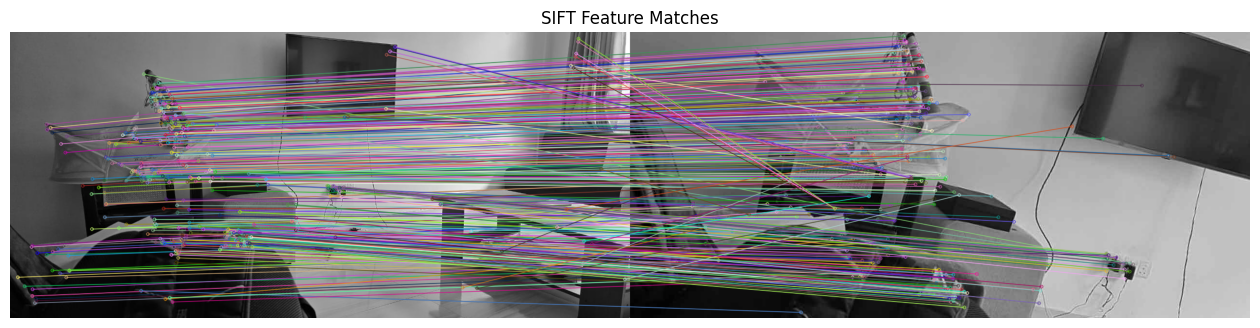

In [6]:
img_matches=cv2.drawMatches(img1, keypoints1,img2,keypoints2,good_matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(16,8))
plt.imshow(img_matches,cmap='gray')
plt.title('SIFT Feature Matches')
plt.axis('off')
plt.show()